# Compare custom implementation of SpliSER

## imports

In [ ]:
import os
import yaml
import pandas as pd
from scipy.stats import pearsonr

import seaborn as sns
import matplotlib.pyplot as plt

from figutils import (
    cm,
    set_figure_style, 
)

set_figure_style()

FIGS_DIR = os.path.join("pdfs","benchmark_get_star_junctions")
os.makedirs(FIGS_DIR, exist_ok=True)

## data

In [2]:
# paths

ROOT = ".."
config = yaml.safe_load(open(os.path.join(ROOT,"config","config.yaml"),"r"))
SAMPLES = config["preprocessing"]["overfitting"]["samples"]
SSU_OUTPUT_DIR = "results/sanity_checks/comparison_ssu"

stats_file = os.path.join(ROOT, SSU_OUTPUT_DIR, "benchmarks", "benchmarks.parquet")

spliser_files = {
    s: os.path.join(ROOT, SSU_OUTPUT_DIR, "spliser", "{sample}", "{sample}.SpliSER.tsv").format(sample=s)
    for s in SAMPLES
}
custom_files = {
    s: os.path.join(ROOT, SSU_OUTPUT_DIR,"custom","{sample}","paper_pass.ssu.parquet").format(sample=s)
    for s in SAMPLES
}

In [3]:
# loads

stats = pd.read_parquet(stats_file)

spliser = pd.concat([
    pd.read_table(f).assign(sample=s)
    for s, f in spliser_files.items()
])

custom = pd.concat([
    pd.read_parquet(f).assign(sample=s)
    for s, f in custom_files.items()
])

## faster custom implementation of spliser

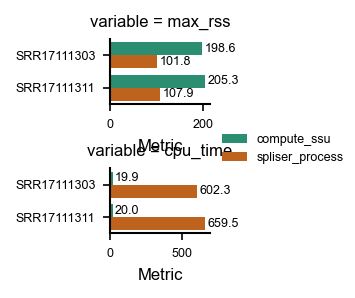

In [4]:
X = (
    stats
    .melt(id_vars=["sample","tool"])
    .query("variable.isin(['cpu_time','max_rss'])")
)

g = sns.catplot(
    kind="bar",
    data=X,
    x="value",
    y="sample",
    hue="tool", palette="Dark2",
    row="variable",
    sharex=False,
    height=2.5*cm, aspect=2
)

for ax in g.axes.flat:
    for container in ax.containers:
        ax.bar_label(
            container,
            fmt="%.1f",
            padding=1,
            fontsize=6
        )
        
g.set(xlabel="Metric", ylabel="", xscale="linear")
g.legend.set_title("")

g.fig.savefig(os.path.join(FIGS_DIR,"performance_vs_sample-bar.pdf"), bbox_inches="tight", dpi=200)

plt.show()

## equivalent SSU (with read quality filter)

In SpliSER, donors are exonic and acceptors intronic

In [5]:
spliser.shape

(82987, 13)

In [6]:
custom.shape

(79433, 14)

In [7]:
spliser.query("Site.isin([14829,248914439-1])")

,Region,Site,Strand,Gene,SSE,alpha_count,beta1_count,beta2_count,MultiGeneFlag,Others,Partners,Competitors,sample
1,chr1,14829,-,NaN,0.962,50,2,0,False,[],{14969: 50},[],SRR17111303
40024,chr1,248914438,+,NaN,0.026,1,0,37,False,[],{248913879: 1},"[248916601, 248917278]",SRR17111303
1,chr1,14829,-,NaN,0.909,30,2,1,False,[],"{14969: 29, 14962: 1}",[14843],SRR17111311
42951,chr1,248914438,+,NaN,0.026,1,2,35,False,[],{248913879: 1},"[248916601, 248917278]",SRR17111311


In [8]:
custom.query("exon_pos.isin([14829,248914439])")

,chrom,strand,role,exon_pos,intron_pos,alpha_juncs,beta2_juncs,ssu_approx,alpha_bam,beta1_bam,beta2_bam,ssu_spliser,ssu_full,sample
1,chr1,-,donor,14829,14830,49,0,1.000000,50.0,2.0,0.0,0.961538,0.960784,SRR17111303
38362,chr1,+,acceptor,248914439,248914438,1,26,0.037037,1.0,0.0,37.0,0.026316,0.037037,SRR17111303
1,chr1,-,donor,14829,14830,28,1,0.965517,30.0,2.0,1.0,0.909091,0.903226,SRR17111311
41065,chr1,+,acceptor,248914439,248914438,1,27,0.035714,1.0,2.0,35.0,0.026316,0.033333,SRR17111311


In [9]:
custom["Site"] = custom["exon_pos"]
custom.loc[custom["role"]=="acceptor","Site"] = custom.loc[custom["role"]=="acceptor","Site"] - 1

X = pd.merge(
    spliser[["sample","Region","Site","Strand","SSE","alpha_count","beta1_count","beta2_count","MultiGeneFlag"]].drop_duplicates(),
    (
        custom[["sample","chrom","Site","strand","role","ssu_spliser","alpha_bam","beta1_bam","beta2_bam"]].drop_duplicates()
        .rename(columns={"chrom":"Region", "strand":"Strand"})
    ),
    on=["Region","Site","Strand","sample"],
    how="inner"
)

# When a donor and an acceptor share the same Site value after coordinate adjustment
# (donor exon_pos == acceptor exon_pos - 1), the merge creates duplicate rows.
# Resolve by keeping the row whose alpha_bam is closest to SpliSER's alpha_count.
X["_alpha_diff"] = (X["alpha_bam"] - X["alpha_count"]).abs()
X = X.loc[
    X.groupby(["sample","Region","Site","Strand"])["_alpha_diff"].transform("min") == X["_alpha_diff"]
].drop(columns=["_alpha_diff","role"]).reset_index(drop=True)

X["diff_ssu"] = X["SSE"] - X["ssu_spliser"]

X

,sample,Region,Site,Strand,SSE,alpha_count,beta1_count,beta2_count,MultiGeneFlag,ssu_spliser,alpha_bam,beta1_bam,beta2_bam,diff_ssu
0,SRR17111303,chr1,13114,+,1.000,1,0,0,False,1.000000,1.0,0.0,0.0,0.000000
1,SRR17111303,chr1,14829,-,0.962,50,2,0,False,0.961538,50.0,2.0,0.0,0.000462
2,SRR17111303,chr1,14969,-,0.962,50,2,0,False,0.961538,50.0,2.0,0.0,0.000462
3,SRR17111303,chr1,15038,-,0.786,11,3,0,False,0.785714,11.0,3.0,0.0,0.000286
4,SRR17111303,chr1,15795,-,1.000,11,0,0,False,1.000000,11.0,0.0,0.0,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
78827,SRR17111311,chr1,248914438,+,0.026,1,2,35,False,0.026316,1.0,2.0,35.0,-0.000316
78828,SRR17111311,chr1,248914559,+,0.023,1,8,35,False,0.022727,1.0,8.0,35.0,0.000273
78829,SRR17111311,chr1,248916601,+,0.784,29,1,7,False,0.783784,29.0,1.0,7.0,0.000216
78830,SRR17111311,chr1,248917007,+,0.128,5,26,8,False,0.128205,5.0,26.0,8.0,-0.000205


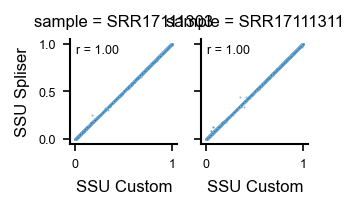

In [10]:
g = sns.relplot(
    kind="scatter",
    data=X,
    x="ssu_spliser",
    y="SSE",
    col="sample",
    s=1, alpha=0.5,
    height=3.5*cm, aspect=0.8
)

for sample, ax in g.axes_dict.items():
    d = X.loc[X["sample"] == sample, ["ssu_spliser", "SSE"]].dropna()

    r, p = pearsonr(d["ssu_spliser"], d["SSE"])

    ax.text(
        0.05, 0.95,
        f"r = {r:.2f}",
        transform=ax.transAxes,
        ha="left",
        va="top"
    )

g.set(xlabel="SSU Custom", ylabel="SSU Spliser")

g.fig.savefig(os.path.join(FIGS_DIR,"ssu_custom_vs_spliser-scatter.pdf"), bbox_inches="tight", dpi=200)

plt.show()

In [11]:
X.sort_values("diff_ssu", ascending=False).head(20)

,sample,Region,Site,Strand,SSE,alpha_count,beta1_count,beta2_count,MultiGeneFlag,ssu_spliser,alpha_bam,beta1_bam,beta2_bam,diff_ssu
57783,SRR17111311,chr1,101075394,+,0.440,55,24,46,False,0.351852,38.0,24.0,46.0,0.088148
18597,SRR17111303,chr1,101075394,+,0.250,29,24,63,False,0.171429,18.0,24.0,63.0,0.078571
38390,SRR17111311,chr1,962615,+,0.125,2,2,12,False,0.066667,1.0,2.0,12.0,0.058333
38389,SRR17111311,chr1,962615,+,0.125,2,2,12,False,0.066667,1.0,2.0,12.0,0.058333
57886,SRR17111311,chr1,101408904,-,0.083,2,1,21,False,0.043478,1.0,2.0,20.0,0.039522
57885,SRR17111311,chr1,101408904,-,0.083,2,1,21,False,0.043478,1.0,1.0,21.0,0.039522
66106,SRR17111311,chr1,156732280,+,0.447,72,75,14,False,0.410596,62.0,82.0,7.0,0.036404
26416,SRR17111303,chr1,156732280,+,0.329,28,45,12,False,0.304878,25.0,53.0,4.0,0.024122
71963,SRR17111311,chr1,200999673,-,0.049,2,0,39,False,0.025000,1.0,0.0,39.0,0.024000
71962,SRR17111311,chr1,200999673,-,0.049,2,0,39,False,0.025000,1.0,0.0,39.0,0.024000


# SSU benchmark: compute_ssu.py vs SpliSER

Comparison of `compute_ssu.py` (BAM-mode, `ssu_spliser` column) against SpliSER `process`
on chr1 for two samples (SRR17111303, SRR17111311).

## Setup

- **Our tool**: `src/alphagenome-pytorch/scripts/compute_ssu.py --bam --chroms chr1`, MAPQ ≥ 30
- **SpliSER**: `spliser process --isStranded -s rf -c chr1`, no MAPQ filter
- **Junction source**: STAR `paper_pass.SJ.out.tab` (≥1 uniquely mapped read); partner/competitor
  maps extended with all BAM-observed junctions via `bam.find_introns` to recover junctions
  absent from SJ.out.tab
- **Notebook**: `figures/benchmark_compute_ssu.ipynb`

## Overall result

SSU values are essentially identical to SpliSER across all well-supported sites (r ≈ 1.000,
mean |ΔSSU| near zero). All residual differences fall into one of three categories explained
below — none represent errors in either implementation.

## Remaining differences and their causes

### 1. Bi-role positions (design difference)

SpliSER uses a **position-centric** site model: one `Site` object per genomic coordinate,
accumulating α reads from every junction that touches that position regardless of whether
the site acts as a donor or acceptor. Our implementation uses a **role-centric** model:
separate donor and acceptor entries for the same coordinate when it appears as both `iv_s`
in one junction and `iv_e` in another.

At these bi-role positions SpliSER reports a single α = donor_α + acceptor_α, while our
output has two rows (one donor, one acceptor) whose α values sum to SpliSER's total. The
comparison notebook resolves this by keeping the row whose `alpha_bam` is closest to
SpliSER's `alpha_count`; the other role is effectively unrepresented in the diff table.
Our role-separated view is more biologically interpretable (donor and acceptor sites have
distinct functional identities).

### 2. SJ.out.tab filtering (expected scope difference)

Our site table is built exclusively from junctions in STAR's `SJ.out.tab` (≥1 uniquely
mapped read). SpliSER discovers sites from all introns visible in the BAM via
`find_introns`, including junctions supported only by multi-mapped reads or with
non-canonical motifs that STAR does not emit to SJ.out.tab.

For a position that is both an acceptor (junction in SJ.out.tab) and a donor (junction
only in BAM), SpliSER counts α from both junctions; our implementation counts only the
SJ.out.tab junction. The resulting α undercounting by 1 at a small number of very
low-coverage sites is expected and intentional: we deliberately rely on STAR's
high-confidence junction calls for site discovery.

### 3. Marginal residual beta2 differences

At a handful of sites with α = 1, a single beta2 read may be classified differently. These
are low-confidence sites where beta2 calls are inherently noisy and the SSU difference is
< 0.015. No systematic pattern has been identified; these are considered negligible.

## Algorithmic differences resolved during development

The following discrepancies were identified and fixed to align our implementation with
SpliSER's logic:

| Issue | Fix |
|---|---|
| Acceptor scan position off by one (`iv_e − 1` instead of `iv_e`) | Changed `a_pos = exon_end − 2` → `exon_end − 1`; updated beta lookup key |
| β1 left boundary inclusive (`bs ≤ target`) should be strict | Changed to `bs < target` for both donor and acceptor |
| Whiteset polluted by antisense-noise reads | Added majority-rule strand collapse (mirrors SpliSER's `collapse_duplicate_introns`) before populating whiteset and partner maps |
| α undercounted due to missing strand-collapsed reads | Derived α directly from the collapsed `_introns_by_strand` dict rather than per-read accumulation, so minority-strand reads are folded into the dominant strand |
| Partner map convention inconsistency after acceptor fix | Updated whiteset extension from `iv_e − 1` to `iv_e` and removed `− 1` from `comp_splicing` lookups |
| Notebook join creating false donor/acceptor collisions | Added deduplication step keeping the row with `alpha_bam` closest to `alpha_count` per (sample, region, site, strand) group |